In [1]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor

In [2]:
df = pd.read_csv('./data/train.csv')
test= pd.read_csv('./data/test.csv')

sample= pd.read_csv('./data/sample_submission.csv')

In [3]:
df

,id,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,268,1002,Dell,Inspiron 5567,Notebook,15.6,1366x768,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,AMD Radeon R7 M445,Windows 10,2.36kg,749.00
1,347,867,Asus,X541NA (N4200/4GB/1TB/W10),Notebook,15.6,1366x768,Intel Pentium Quad Core N4200 1.1GHz,4GB,1TB HDD,Intel HD Graphics 505,Windows 10,2kg,449.00
2,353,966,Toshiba,Portege Z30-C-1CW,Notebook,13.3,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 7,1.2kg,1460.00
3,578,767,Dell,Alienware 17,Gaming,15.6,IPS Panel 4K Ultra HD 3840x2160,Intel Core i7 7700HQ 2.8GHz,16GB,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1070,Windows 10,4.42kg,2868.99
4,42,1241,Dell,Latitude E7270,Ultrabook,12.5,Full HD / Touchscreen 1920x1080,Intel Core i5 6300U 2.4GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 7,1.26kg,1713.37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
907,89,973,Acer,Chromebook C738T-C2EJ,2 in 1 Convertible,11.6,IPS Panel Touchscreen 1366x768,Intel Celeron Dual Core N3060 1.6GHz,4GB,32GB Flash Storage,Intel HD Graphics 400,Chrome OS,1.25kg,389.00
908,716,1018,Toshiba,Portege Z30-C-16H,Notebook,13.3,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.2kg,1195.00
909,517,1071,Acer,Aspire ES1-523,Notebook,15.6,1366x768,AMD A8-Series 7410 2.2GHz,8GB,1TB HDD,AMD Radeon R5,Windows 10,2.4kg,449.00
910,891,965,Dell,Latitude 7480,Ultrabook,14.0,Full HD 1920x1080,Intel Core i7 7600U 2.8GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.36kg,1775.00


In [4]:
df['Gpu'].value_counts()

Gpu
Intel HD Graphics 620      199
Intel HD Graphics 520      138
Intel UHD Graphics 620      45
Nvidia GeForce GTX 1050     43
Nvidia GeForce GTX 1060     31
                          ... 
AMD FirePro W6150M           1
AMD Radeon R7 Graphics       1
AMD Radeon R7                1
Intel Graphics 620           1
Nvidia Quadro M520M          1
Name: count, Length: 91, dtype: int64

In [5]:
df.sort_values('Price_euros',  ascending = False)


,id,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
73,909,200,Razer,Blade Pro,Gaming,17.3,4K Ultra HD / Touchscreen 3840x2160,Intel Core i7 7820HK 2.9GHz,32GB,1TB SSD,Nvidia GeForce GTX 1080,Windows 10,3.49kg,6099.0
837,73,839,Razer,Blade Pro,Gaming,17.3,4K Ultra HD / Touchscreen 3840x2160,Intel Core i7 7820HK 2.9GHz,32GB,512GB SSD,Nvidia GeForce GTX 1080,Windows 10,3.49kg,5499.0
18,518,617,Lenovo,Thinkpad P51,Notebook,15.6,IPS Panel 4K Ultra HD 3840x2160,Intel Xeon E3-1535M v6 3.1GHz,32GB,1TB SSD,Nvidia Quadro M2200M,Windows 10,2.5kg,4899.0
789,202,758,HP,Zbook 17,Workstation,17.3,IPS Panel Full HD 1920x1080,Intel Xeon E3-1535M v5 2.9GHz,16GB,256GB SSD,Nvidia Quadro M2000M,Windows 7,3kg,4389.0
567,1170,1151,HP,ZBook 17,Workstation,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,8GB,256GB SSD,Nvidia Quadro M3000M,Windows 7,3kg,3949.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357,526,800,Vero,K146 (N3350/4GB/32GB/W10),Notebook,14.0,1920x1080,Intel Celeron Dual Core N3350 1.1GHz,4GB,32GB Flash Storage,Intel HD Graphics 500,Windows 10,1.22kg,202.9
215,1002,32,Asus,E402WA-GA010T (E2-6110/2GB/32GB/W10),Notebook,14.0,1366x768,AMD E-Series E2-6110 1.5GHz,2GB,32GB Flash Storage,AMD Radeon R2,Windows 10,1.65kg,199.0
739,664,295,Acer,Chromebook C910-C2ST,Notebook,15.6,1366x768,Intel Celeron Dual Core 3205U 1.5GHz,2GB,16GB SSD,Intel HD Graphics,Chrome OS,2.19kg,199.0
538,422,21,Asus,Vivobook E200HA,Netbook,11.6,1366x768,Intel Atom x5-Z8350 1.44GHz,2GB,32GB Flash Storage,Intel HD Graphics 400,Windows 10,0.98kg,191.9


In [6]:
df['Cpu'].value_counts()

Cpu
Intel Core i5 7200U 2.5GHz              142
Intel Core i7 7700HQ 2.8GHz             102
Intel Core i7 7500U 2.7GHz               88
Intel Core i5 8250U 1.6GHz               54
Intel Core i5 6200U 2.3GHz               51
                                       ... 
Intel Pentium Quad Core N3700 1.6GHz      1
AMD A6-Series A6-9220 2.5GHz              1
AMD A9-Series 9420 2.9GHz                 1
AMD A6-Series 9220 2.9GHz                 1
AMD E-Series 9000 2.2GHz                  1
Name: count, Length: 104, dtype: int64

In [7]:
#ram
df['Ram'] = df['Ram'].str.replace('GB', '')
df['Ram'] = df['Ram'].astype(int)

In [8]:
#peso
df['Weight'] = df['Weight'].str.replace('kg', '')
df['Weight'] = df['Weight'].astype(float)

In [9]:
#ScreenResolution	
def process_resolution(res):
   
    touchscreen = 1 if "Touchscreen" in res else 0
    ips_panel = 1 if "IPS Panel" in res else 0
    full_hd = 1 if "Full HD" in res or "1920x1080" in res else 0  
    four_k = 1 if "4K" in res or "3840x2160" in res else 0 

   
    res_split = [s for s in res.split() if 'x' in s]  
    if res_split:
        width, height = map(int, res_split[0].split('x'))
    else:
        width, height = None, None  # Si no encuentra resolución

    return pd.Series([width, height, touchscreen, full_hd, four_k, ips_panel])


df[['Width', 'Height', 'Touchscreen', 'Full_HD', '4K', 'IPS_Panel']] = df['ScreenResolution'].apply(process_resolution)


df.drop(columns=['ScreenResolution'], inplace=True)





In [10]:
# Función para procesar la columna Memory
def process_memory(mem):
    mem = mem.upper().replace(" ", "")  # Quitar espacios y uniformizar a mayúsculas
    storage_types = ["SSD", "HDD", "FLASHSTORAGE", ]  # Posibles tipos de almacenamiento

    total_capacity_gb = 0
    storage_dict = {stype: 0 for stype in storage_types}  # Inicializar cada tipo en 0

    # Separar diferentes tipos de almacenamiento si están combinados (ej. "128GB SSD + 1TB HDD")
    parts = mem.split("+")
    
    for part in parts:
        # Extraer capacidad (GB o TB)
        if "TB" in part:
            capacity = float(part.split("TB")[0]) * 1024  # Convertir TB a GB (usando float)
        elif "GB" in part:
            capacity = float(part.split("GB")[0])  # Usar float para manejar decimales
        else:
            continue  # Si no tiene TB o GB, ignorar

        # Identificar el tipo de almacenamiento (SSD, HDD, etc.)
        for stype in storage_types:
            if stype in part:
                storage_dict[stype] += capacity  # Sumar capacidad al tipo correspondiente
                total_capacity_gb += capacity
                break

    return pd.Series([total_capacity_gb] + list(storage_dict.values()))

# Aplicar la función a la columna
df[['Total_Storage_GB', 'SSD_GB', 'HDD_GB', 'FlashStorage_GB', ]] = df['Memory'].apply(process_memory)

# Eliminar la columna original
df.drop(columns=['Memory'], inplace=True)






In [11]:

# Función para procesar la columna CPU
def process_cpu(cpu):
    # Extraer marca (Intel, AMD, etc.)
    brand = re.findall(r"Intel|AMD", cpu)  # Puede agregar más marcas si es necesario
    brand = brand[0] if brand else "Unknown"  # Si no se encuentra, asignamos "Unknown"

    # Extraer familia de CPU (Core i5, i7, etc.)
    family = re.findall(r"Core i[5-9]", cpu)  # i5, i7, i9
    family = family[0] if family else "Unknown"  # Si no se encuentra, asignamos "Unknown"
    
    # Extraer la frecuencia (Ejemplo: 2.5GHz, 2.8GHz)
    freq = re.findall(r"\d+\.\d+GHz", cpu)
    freq = float(freq[0].replace("GHz", "")) if freq else 0.0  # Si no se encuentra, asignamos 0.0GHz

    # Extraer número de núcleos (si está presente, como "Quad Core")
    cores = re.findall(r"(Quad|Dual) Core", cpu)
    cores = cores[0] if cores else "Unknown"

    # Mapear el número de núcleos a un valor numérico (Quad = 4, Dual = 2)
    num_cores = 4 if cores == "Quad" else (2 if cores == "Dual" else 1)  # Si no se encuentra, asignamos 1

    return pd.Series([brand, family, freq, num_cores])

# Aplicar la función a la columna CPU
df[['Brand', 'Family', 'Frequency_GHz', 'Num_Cores']] = df['Cpu'].apply(process_cpu)

# Eliminar la columna original
df.drop(columns=['Cpu'], inplace=True)






In [12]:


# Función para procesar la columna Gpu
def process_gpu(gpu):
    # Extraer la marca de la GPU (Intel, Nvidia, AMD)
    brand = re.findall(r"Intel|Nvidia|AMD", gpu)
    brand = brand[0] if brand else "Unknown"  # Si no se encuentra, asignamos "Unknown"
    
    # Extraer el modelo de la GPU (como GTX 1050, Radeon R7, etc.)
    model = re.findall(r"(GTX \d{3,4}|GeForce \w+|Radeon \w+|Quadro \w+|FirePro \w+)", gpu)
    model = model[0] if model else "Unknown"  # Si no se encuentra, asignamos "Unknown"
    
    return pd.Series([brand, model])

# Aplicar la función a la columna Gpu
df[['Gpu_Brand', 'Gpu_Model']] = df['Gpu'].apply(process_gpu)

# Eliminar la columna original
df.drop(columns=['Gpu'], inplace=True)




In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                912 non-null    int64  
 1   laptop_ID         912 non-null    int64  
 2   Company           912 non-null    object 
 3   Product           912 non-null    object 
 4   TypeName          912 non-null    object 
 5   Inches            912 non-null    float64
 6   Ram               912 non-null    int64  
 7   OpSys             912 non-null    object 
 8   Weight            912 non-null    float64
 9   Price_euros       912 non-null    float64
 10  Width             912 non-null    int64  
 11  Height            912 non-null    int64  
 12  Touchscreen       912 non-null    int64  
 13  Full_HD           912 non-null    int64  
 14  4K                912 non-null    int64  
 15  IPS_Panel         912 non-null    int64  
 16  Total_Storage_GB  912 non-null    float64
 1

In [14]:
#compruebo que no existan nulos
df.isna().sum()

id                  0
laptop_ID           0
Company             0
Product             0
TypeName            0
Inches              0
Ram                 0
OpSys               0
Weight              0
Price_euros         0
Width               0
Height              0
Touchscreen         0
Full_HD             0
4K                  0
IPS_Panel           0
Total_Storage_GB    0
SSD_GB              0
HDD_GB              0
FlashStorage_GB     0
Brand               0
Family              0
Frequency_GHz       0
Num_Cores           0
Gpu_Brand           0
Gpu_Model           0
dtype: int64

In [15]:
dfn = df.select_dtypes(include=['number'])

In [16]:
dfn

,id,laptop_ID,Inches,Ram,Weight,Price_euros,Width,Height,Touchscreen,Full_HD,4K,IPS_Panel,Total_Storage_GB,SSD_GB,HDD_GB,FlashStorage_GB,Frequency_GHz,Num_Cores
0,268,1002,15.6,8,2.36,749.00,1366,768,0,0,0,0,1024.0,0.0,1024.0,0.0,2.7,1
1,347,867,15.6,4,2.00,449.00,1366,768,0,0,0,0,1024.0,0.0,1024.0,0.0,1.1,4
2,353,966,13.3,8,1.20,1460.00,1920,1080,0,1,0,0,256.0,256.0,0.0,0.0,2.3,1
3,578,767,15.6,16,4.42,2868.99,3840,2160,0,0,1,1,1280.0,256.0,1024.0,0.0,2.8,1
4,42,1241,12.5,8,1.26,1713.37,1920,1080,1,1,0,0,256.0,256.0,0.0,0.0,2.4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
907,89,973,11.6,4,1.25,389.00,1366,768,1,0,0,1,32.0,0.0,0.0,32.0,1.6,2
908,716,1018,13.3,4,1.20,1195.00,1920,1080,0,1,0,0,128.0,128.0,0.0,0.0,2.3,1
909,517,1071,15.6,8,2.40,449.00,1366,768,0,0,0,0,1024.0,0.0,1024.0,0.0,2.2,1
910,891,965,14.0,8,1.36,1775.00,1920,1080,0,1,0,0,256.0,256.0,0.0,0.0,2.8,1


<Axes: >

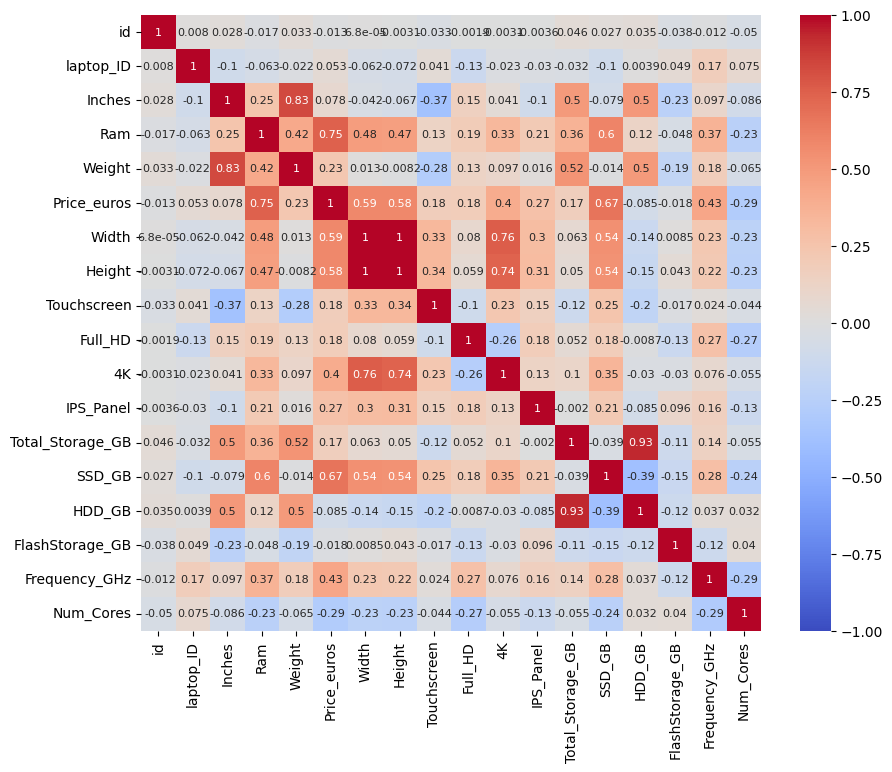

In [17]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(dfn.corr(), annot=True, cmap='coolwarm', vmin=-1, annot_kws={"size": 8}, ax=ax)



In [18]:
dfn

,id,laptop_ID,Inches,Ram,Weight,Price_euros,Width,Height,Touchscreen,Full_HD,4K,IPS_Panel,Total_Storage_GB,SSD_GB,HDD_GB,FlashStorage_GB,Frequency_GHz,Num_Cores
0,268,1002,15.6,8,2.36,749.00,1366,768,0,0,0,0,1024.0,0.0,1024.0,0.0,2.7,1
1,347,867,15.6,4,2.00,449.00,1366,768,0,0,0,0,1024.0,0.0,1024.0,0.0,1.1,4
2,353,966,13.3,8,1.20,1460.00,1920,1080,0,1,0,0,256.0,256.0,0.0,0.0,2.3,1
3,578,767,15.6,16,4.42,2868.99,3840,2160,0,0,1,1,1280.0,256.0,1024.0,0.0,2.8,1
4,42,1241,12.5,8,1.26,1713.37,1920,1080,1,1,0,0,256.0,256.0,0.0,0.0,2.4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
907,89,973,11.6,4,1.25,389.00,1366,768,1,0,0,1,32.0,0.0,0.0,32.0,1.6,2
908,716,1018,13.3,4,1.20,1195.00,1920,1080,0,1,0,0,128.0,128.0,0.0,0.0,2.3,1
909,517,1071,15.6,8,2.40,449.00,1366,768,0,0,0,0,1024.0,0.0,1024.0,0.0,2.2,1
910,891,965,14.0,8,1.36,1775.00,1920,1080,0,1,0,0,256.0,256.0,0.0,0.0,2.8,1


## Base Line Model

In [19]:
X = np.array(dfn.drop(columns=['Price_euros']))
y = np.array(dfn['Price_euros'])

In [20]:
#X = df[['Inches', 'Inches', 'Ram', 'SSD_GB', 'Frequency_GHz', 'Width', 'Height']]
#y = df['Price_euros']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(638, 17)
(274, 17)
(638,)
(274,)


In [22]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [23]:
y_pred = lr.predict(X_test)
print("R2 score", lr.score(X_test, y_test))
print("MAE", mean_absolute_error(y_test, y_pred))

R2 score 0.6948763164365517
MAE 265.6934249361696


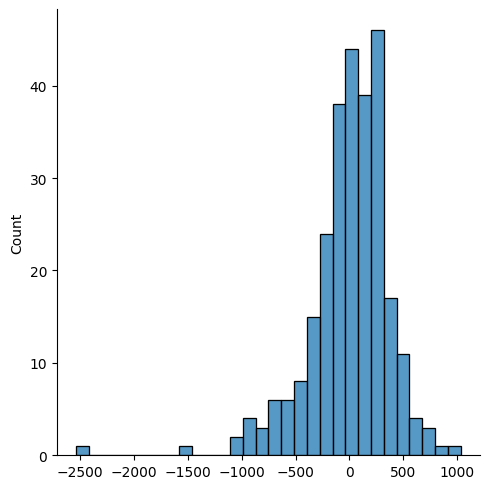

In [24]:
sns.displot(y_pred - y_test)

In [25]:
#Creo la función para probar y mejorar los modelos

def train_evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print("R2 score", model.score(X_test, y_test))
    print("MAE", mean_absolute_error(y_test, y_pred))
    return model

In [26]:
scaler = StandardScaler()

X_train_scal = scaler.fit_transform(X_train)
X_test_scal = scaler.transform(X_test)

pd.DataFrame(X_train_scal).describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
count,6.380000e+02,6.380000e+02,6.380000e+02,6.380000e+02,6.380000e+02,6.380000e+02,6.380000e+02,6.380000e+02,6.380000e+02,6.380000e+02,6.380000e+02,6.380000e+02,6.380000e+02,6.380000e+02,6.380000e+02,6.380000e+02,6.380000e+02
mean,1.670555e-17,6.821433e-17,-7.646409e-14,1.392129e-17,-2.226015e-15,-8.352775e-17,-3.174055e-16,3.897962e-17,3.341110e-17,-6.682220e-17,-4.176388e-17,-9.466478e-17,3.341110e-17,2.505833e-17,-1.392129e-17,3.339718e-15,5.011665e-17
std,1.000785e+00,1.000785e+00,1.000785e+00,1.000785e+00,1.000785e+00,1.000785e+00,1.000785e+00,1.000785e+00,1.000785e+00,1.000785e+00,1.000785e+00,1.000785e+00,1.000785e+00,1.000785e+00,1.000785e+00,1.000785e+00,1.000785e+00
min,-1.704323e+00,-1.754331e+00,-3.653199e+00,-1.219347e+00,-2.105612e+00,-1.008090e+00,-1.008095e+00,-4.078749e-01,-1.331883e+00,-2.019481e-01,-5.906244e-01,-1.282155e+00,-9.657220e-01,-8.170562e-01,-1.590546e-01,-2.818890e+00,-2.660952e-01
25%,-8.374384e-01,-8.399801e-01,-8.068268e-01,-8.321177e-01,-6.693743e-01,-1.008090e+00,-1.008095e+00,-4.078749e-01,-1.331883e+00,-2.019481e-01,-5.906244e-01,-7.420777e-01,-9.657220e-01,-8.170562e-01,-1.590546e-01,-4.681434e-01,-2.660952e-01
50%,-2.333249e-02,-1.252177e-02,3.609157e-01,-5.765951e-02,-2.001135e-02,7.400256e-02,5.953442e-02,-4.078749e-01,7.508165e-01,-2.019481e-01,-5.906244e-01,-2.273162e-01,-1.286766e-01,-8.170562e-01,-1.590546e-01,4.460360e-01,-2.660952e-01
75%,8.798369e-01,8.695739e-01,3.609157e-01,-5.765951e-02,3.543273e-01,7.400256e-02,5.953442e-02,-4.078749e-01,7.508165e-01,-2.019481e-01,1.693123e+00,8.781552e-01,4.257301e-01,1.144695e+00,-1.590546e-01,7.072301e-01,-2.660952e-01
max,1.728908e+00,1.718755e+00,2.404465e+00,4.589090e+00,3.868527e+00,3.824216e+00,3.755174e+00,2.451732e+00,7.508165e-01,4.951767e+00,1.693123e+00,4.118621e+00,4.600086e+00,3.106447e+00,1.119500e+01,1.882604e+00,5.392863e+00


In [27]:
scaler = MinMaxScaler()

X_train_scal = scaler.fit_transform(X_train)
X_test_scal = scaler.transform(X_test)

pd.DataFrame(X_train_scal).describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
count,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000
mean,0.496419,0.505122,0.603071,0.209927,0.352455,0.208615,0.211639,0.142633,0.639498,0.039185,0.258621,0.237402,0.173510,0.208247,0.014009,0.599573,0.047022
std,0.291499,0.288154,0.165210,0.172298,0.167519,0.207103,0.210105,0.349973,0.480523,0.194187,0.438220,0.185304,0.179809,0.255074,0.088143,0.212865,0.176850
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.252498,0.263268,0.469880,0.066667,0.240409,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.100000,0.000000,0.000000,0.000000,0.500000,0.000000
50%,0.489623,0.501516,0.662651,0.200000,0.349105,0.223929,0.224138,0.000000,1.000000,0.000000,0.000000,0.195312,0.150391,0.000000,0.000000,0.694444,0.000000
75%,0.752690,0.755497,0.662651,0.200000,0.411765,0.223929,0.224138,0.000000,1.000000,0.000000,1.000000,0.400000,0.250000,0.500000,0.000000,0.750000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [28]:
scaler = train_evaluate_model(LinearRegression(), X_train_scal, y_train, X_test_scal, y_test)


R2 score 0.6948763164365528
MAE 265.6934249361695


In [29]:
model_1 = train_evaluate_model(Ridge(alpha=100), X_train, y_train, X_test, y_test)


R2 score 0.6956968475877918
MAE 263.51660079155675


In [30]:
 #model_test(X, y)

In [31]:
# modelo final 
rf = RandomForestRegressor()
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf.fit(x_train, y_train)
predictions = rf.predict(x_test)

In [32]:
print("R2 score", rf.score(x_test, y_test))
print("MAE", mean_absolute_error(y_test, predictions))

R2 score 0.7286987736509306
MAE 212.05520109289617


--- 

In [33]:
test 

,id,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
0,181,1098,HP,Spectre x360,Ultrabook,13.3,IPS Panel 4K Ultra HD 3840x2160,Intel Core i7 7500U 2.7GHz,16GB,512GB SSD,Intel HD Graphics 620,Windows 10,1.3kg
1,708,330,Acer,Aspire 5,Notebook,15.6,1366x768,AMD A12-Series 9720P 2.7GHz,8GB,256GB SSD,AMD Radeon RX 540,Windows 10,2.2kg
2,862,1260,Acer,Aspire ES1-572,Notebook,15.6,1366x768,Intel Core i3 6006U 2.0GHz,4GB,500GB HDD,Intel HD Graphics 520,Linux,2.4kg
3,1064,1137,HP,EliteBook 1040,Notebook,14.0,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 7,1.43kg
4,702,1015,HP,ENVY -,Notebook,13.3,IPS Panel Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.34kg
...,...,...,...,...,...,...,...,...,...,...,...,...,...
386,1281,145,Lenovo,Legion Y520-15IKBN,Gaming,15.6,IPS Panel Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,8GB,256GB SSD,Nvidia GeForce GTX 1050M,No OS,2.4kg
387,524,1195,Lenovo,IdeaPad Y700-15ISK,Gaming,15.6,IPS Panel Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,16GB,512GB SSD,Nvidia GeForce GTX 960,Windows 10,3.31kg
388,1015,1070,HP,250 G5,Notebook,15.6,1366x768,Intel Core i5 7200U 2.5GHz,4GB,500GB HDD,Intel HD Graphics 620,No OS,1.96kg
389,1236,104,HP,15-bw000nv (E2-9000e/4GB/500GB/Radeon,Notebook,15.6,Full HD 1920x1080,AMD E-Series E2-9000e 1.5GHz,4GB,500GB HDD,AMD Radeon R2,Windows 10,2.1kg


In [34]:
test['Ram'] = test['Ram'].str.replace('GB', '')
test['Ram'] = test['Ram'].astype(int)


In [35]:
#peso
test['Weight'] = test['Weight'].str.replace('kg', '')
test['Weight'] = test['Weight'].astype(float)

In [36]:
def process_resolution(res):
   
    touchscreen = 1 if "Touchscreen" in res else 0
    ips_panel = 1 if "IPS Panel" in res else 0
    full_hd = 1 if "Full HD" in res or "1920x1080" in res else 0  
    four_k = 1 if "4K" in res or "3840x2160" in res else 0 

   
    res_split = [s for s in res.split() if 'x' in s]  
    if res_split:
        width, height = map(int, res_split[0].split('x'))
    else:
        width, height = None, None  # Si no encuentra resolución

    return pd.Series([width, height, touchscreen, full_hd, four_k, ips_panel])


test[['Width', 'Height', 'Touchscreen', 'Full_HD', '4K', 'IPS_Panel']] = test['ScreenResolution'].apply(process_resolution)


test.drop(columns=['ScreenResolution'], inplace=True)

In [37]:
# Función para procesar la columna Memory
def process_memory(mem):
    mem = mem.upper().replace(" ", "")  # Quitar espacios y uniformizar a mayúsculas
    storage_types = ["SSD", "HDD", "FLASHSTORAGE", ]  # Posibles tipos de almacenamiento

    total_capacity_gb = 0
    storage_dict = {stype: 0 for stype in storage_types}  # Inicializar cada tipo en 0

    # Separar diferentes tipos de almacenamiento si están combinados (ej. "128GB SSD + 1TB HDD")
    parts = mem.split("+")
    
    for part in parts:
        # Extraer capacidad (GB o TB)
        if "TB" in part:
            capacity = float(part.split("TB")[0]) * 1024  # Convertir TB a GB (usando float)
        elif "GB" in part:
            capacity = float(part.split("GB")[0])  # Usar float para manejar decimales
        else:
            continue  # Si no tiene TB o GB, ignorar

        # Identificar el tipo de almacenamiento (SSD, HDD, etc.)
        for stype in storage_types:
            if stype in part:
                storage_dict[stype] += capacity  # Sumar capacidad al tipo correspondiente
                total_capacity_gb += capacity
                break

    return pd.Series([total_capacity_gb] + list(storage_dict.values()))

# Aplicar la función a la columna
test[['Total_Storage_GB', 'SSD_GB', 'HDD_GB', 'FlashStorage_GB', ]] = test['Memory'].apply(process_memory)

# Eliminar la columna original
test.drop(columns=['Memory'], inplace=True)






In [38]:

# Función para procesar la columna CPU
def process_cpu(cpu):
    # Extraer marca (Intel, AMD, etc.)
    brand = re.findall(r"Intel|AMD", cpu)  # Puede agregar más marcas si es necesario
    brand = brand[0] if brand else "Unknown"  # Si no se encuentra, asignamos "Unknown"

    # Extraer familia de CPU (Core i5, i7, etc.)
    family = re.findall(r"Core i[5-9]", cpu)  # i5, i7, i9
    family = family[0] if family else "Unknown"  # Si no se encuentra, asignamos "Unknown"
    
    # Extraer la frecuencia (Ejemplo: 2.5GHz, 2.8GHz)
    freq = re.findall(r"\d+\.\d+GHz", cpu)
    freq = float(freq[0].replace("GHz", "")) if freq else 0.0  # Si no se encuentra, asignamos 0.0GHz

    # Extraer número de núcleos (si está presente, como "Quad Core")
    cores = re.findall(r"(Quad|Dual) Core", cpu)
    cores = cores[0] if cores else "Unknown"

    # Mapear el número de núcleos a un valor numérico (Quad = 4, Dual = 2)
    num_cores = 4 if cores == "Quad" else (2 if cores == "Dual" else 1)  # Si no se encuentra, asignamos 1

    return pd.Series([brand, family, freq, num_cores])

# Aplicar la función a la columna CPU
test[['Brand', 'Family', 'Frequency_GHz', 'Num_Cores']] = test['Cpu'].apply(process_cpu)

# Eliminar la columna original
test.drop(columns=['Cpu'], inplace=True)






In [39]:


# Función para procesar la columna Gpu
def process_gpu(gpu):
    # Extraer la marca de la GPU (Intel, Nvidia, AMD)
    brand = re.findall(r"Intel|Nvidia|AMD", gpu)
    brand = brand[0] if brand else "Unknown"  # Si no se encuentra, asignamos "Unknown"
    
    # Extraer el modelo de la GPU (como GTX 1050, Radeon R7, etc.)
    model = re.findall(r"(GTX \d{3,4}|GeForce \w+|Radeon \w+|Quadro \w+|FirePro \w+)", gpu)
    model = model[0] if model else "Unknown"  # Si no se encuentra, asignamos "Unknown"
    
    return pd.Series([brand, model])

# Aplicar la función a la columna Gpu
test[['Gpu_Brand', 'Gpu_Model']] = test['Gpu'].apply(process_gpu)

# Eliminar la columna original
test.drop(columns=['Gpu'], inplace=True)




In [40]:
test

,id,laptop_ID,Company,Product,TypeName,Inches,Ram,OpSys,Weight,Width,...,Total_Storage_GB,SSD_GB,HDD_GB,FlashStorage_GB,Brand,Family,Frequency_GHz,Num_Cores,Gpu_Brand,Gpu_Model
0,181,1098,HP,Spectre x360,Ultrabook,13.3,16,Windows 10,1.30,3840,...,512.0,512.0,0.0,0.0,Intel,Core i7,2.7,1,Intel,Unknown
1,708,330,Acer,Aspire 5,Notebook,15.6,8,Windows 10,2.20,1366,...,256.0,256.0,0.0,0.0,AMD,Unknown,2.7,1,AMD,Radeon RX
2,862,1260,Acer,Aspire ES1-572,Notebook,15.6,4,Linux,2.40,1366,...,500.0,0.0,500.0,0.0,Intel,Unknown,2.0,1,Intel,Unknown
3,1064,1137,HP,EliteBook 1040,Notebook,14.0,8,Windows 7,1.43,1920,...,256.0,256.0,0.0,0.0,Intel,Core i5,2.3,1,Intel,Unknown
4,702,1015,HP,ENVY -,Notebook,13.3,8,Windows 10,1.34,1920,...,256.0,256.0,0.0,0.0,Intel,Core i5,2.5,1,Intel,Unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
386,1281,145,Lenovo,Legion Y520-15IKBN,Gaming,15.6,8,No OS,2.40,1920,...,256.0,256.0,0.0,0.0,Intel,Core i7,2.8,1,Nvidia,GeForce GTX
387,524,1195,Lenovo,IdeaPad Y700-15ISK,Gaming,15.6,16,Windows 10,3.31,1920,...,512.0,512.0,0.0,0.0,Intel,Core i7,2.6,1,Nvidia,GeForce GTX
388,1015,1070,HP,250 G5,Notebook,15.6,4,No OS,1.96,1366,...,500.0,0.0,500.0,0.0,Intel,Core i5,2.5,1,Intel,Unknown
389,1236,104,HP,15-bw000nv (E2-9000e/4GB/500GB/Radeon,Notebook,15.6,4,Windows 10,2.10,1920,...,500.0,0.0,500.0,0.0,AMD,Unknown,1.5,1,AMD,Radeon R2


In [41]:
test = test.select_dtypes(include=['number'])

In [42]:
prediction_test = rf.predict(test) 
prediction_test

c:\Users\borja\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


array([1943.4759,  915.5058,  462.7997, 1479.0226, 1490.2994, 1667.3872,
       1975.467 ,  746.6455, 3365.9218, 1444.0374, 1473.5794,  658.5616,
        462.3284,  630.5237,  515.7877, 1372.899 ,  541.667 , 1571.3724,
       1260.9189, 1674.1945, 2278.9992, 1486.5966, 1647.3913, 1414.0431,
       1951.63  ,  486.3824,  800.6269,  603.8692, 1414.6529,  463.3151,
       1591.1825, 1471.6846, 2054.8704,  514.7899,  525.1673, 1826.0827,
        851.9421,  635.0278, 3002.4348,  606.3875,  683.0199,  907.4938,
       1623.5356, 1822.2926, 1055.1801, 1813.521 ,  669.5797, 3683.5676,
        310.4125, 1551.347 , 1289.7588,  923.24  ,  980.7478,  357.2287,
       1190.4637,  689.4304, 1132.7399,  253.79  , 1418.0478,  956.5731,
       1381.9404, 1193.79  ,  507.4447, 1121.5863, 1411.6686, 1604.4218,
        635.4301, 2406.5098,  477.1894, 1826.1714,  694.2691, 2928.055 ,
        921.5407, 1007.51  , 1231.9239, 1354.2097,  944.6159,  504.7666,
       1375.7822, 1024.04  ,  284.4834, 1298.0969, 

In [43]:
test['Price_euros'] = rf.predict(test) 


c:\Users\borja\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


In [44]:
borja = test[['id' , 'Price_euros']]

In [45]:
borja

,id,Price_euros
0,181,1943.4759
1,708,915.5058
2,862,462.7997
3,1064,1479.0226
4,702,1490.2994
...,...,...
386,1281,1237.2525
387,524,2065.5555
388,1015,731.9858
389,1236,449.8409


In [46]:
borja.to_csv('prediccion_final.csv' , index=False, header= True)